In [8]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

# Test Set

In [4]:
# Load data
def load_and_preprocess(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    rows = []
    label_mapping = {"yes": 1, "no": 0, "maybe": 2}

    for pmid, item in data.items():
        question = item["QUESTION"]
        contexts = " ".join(item["CONTEXTS"])

        rows.append({
            "pmid": pmid,
            "text": f"{question} {contexts}",
            "label": label_mapping[item["final_decision"]]
        })

    return pd.DataFrame(rows)

# Merge training with dev data
all_train_dfs = []

for fold in range(10):
    train_path = f"data/pqal_fold{fold}/train_set.json"
    dev_path = f"data/pqal_fold{fold}/dev_set.json"

    train_df = load_and_preprocess(train_path)
    dev_df = load_and_preprocess(dev_path)

    # Combine both — since across folds, dev sets are just held-out splits
    all_train_dfs.append(train_df)
    all_train_dfs.append(dev_df)

# Merge everything
full_train_df = pd.concat(all_train_dfs, ignore_index=True)

# Prepare test data
test_path = f"data/test_set.json"
test_df = load_and_preprocess(test_path)

 # TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
X_full_train = vectorizer.fit_transform(full_train_df['text'])
X_test = vectorizer.transform(test_df['text'])

y_full_train = full_train_df['label']
y_test = test_df['label']

# Model
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_full_train, y_full_train)

# Predict
preds_test = model.predict(X_test)
probs_test = model.predict_proba(X_test)

# Per fold metrics
acc = accuracy_score(y_test, preds_test)

p, r, f, _ = precision_recall_fscore_support(
    y_test, preds_test, average='macro', zero_division=0)

print(f"Accuracy: {acc:.3f} | F1 macro: {f:.3f}")

Accuracy: 0.514 | F1 macro: 0.309


# Error Analysis

In [5]:
y_true = np.array(y_test)
y_pred = preds_test

y_true_array = np.array(y_test)
y_pred_array = np.array(y_pred)
confidence = probs_test.max(axis=1)

# Indices of errors
wrong_idx = np.where(y_true_array != y_pred_array)[0]

# Label mapping
reverse_mapping = {1:"yes", 0:"no", 2:"maybe"}

# DataFrame of errors for analysis
errors_df = test_df.iloc[wrong_idx].copy()
errors_df['label'] = errors_df['label'].map(reverse_mapping)
errors_df['true_label'] = y_true_array[wrong_idx]
errors_df['pred_label'] = y_pred_array[wrong_idx]
errors_df['confidence'] = confidence[wrong_idx]
errors_df['pred_probs'] = list(probs_test[wrong_idx])

In [6]:
# Sort errors by confidence
errors_df = errors_df.sort_values(by='confidence', ascending=False)

# Print top 5 errors with the highest confidence
for i in range(len(errors_df.iloc[:5])):
    print("TEXT:", errors_df.iloc[i]['text'])
    print("TRUE:", errors_df.iloc[i]['true_label'], "PRED:", errors_df.iloc[i]['pred_label'], "CONF:", errors_df.iloc[i]['confidence'])
    print("-" * 50)

TEXT: Double reading of barium enemas: is it necessary? The purpose of our study was to determine the effectiveness, clinical impact, and feasibility of double reading barium enemas. Independent double readings of 1,003 consecutive barium enemas (822 double- and 181 single-contrast examinations) were prospectively performed. From this pool of 1,003 examinations, 994 were included in our study. Examinations showing at least one polyp or carcinoma 5 mm or larger were considered to have positive results. For combined readings, results were considered positive if either of the two interpreters reported finding a polyp or carcinoma. A McNemar test was used to compare the first reader's results with the combined results of the first and second readers. Results were retrospectively correlated with endoscopic or surgical results in 360 patients, and agreement between first and combined readings and endoscopic results was determined. Adding a second reader increased the number of positive resul

In [7]:
# Proportions of most errors per class
error_counts = errors_df.groupby('true_label')['pred_label'].count()
class_total = pd.Series(y_true_array).value_counts()
error_rate = error_counts / class_total
print(error_rate)

0    0.781065
1    0.202899
2    1.000000
dtype: float64


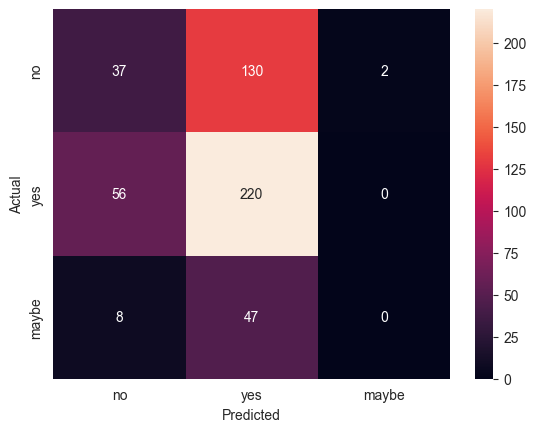

In [9]:
# Confusion matrix to show which classes are being confused

cm = confusion_matrix(y_true_array, y_pred_array)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["no","yes","maybe"],
            yticklabels=["no","yes","maybe"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
from collections import Counter

all_error_text = " ".join(errors_df['text'])
words = all_error_text.split()
counter = Counter(words)
print(counter.most_common(50))

[('of', 1988), ('the', 1962), ('and', 1766), ('in', 1258), ('to', 904), ('with', 764), ('were', 748), ('a', 721), ('was', 700), ('for', 591), ('patients', 555), ('The', 450), ('=', 267), ('from', 240), ('between', 225), ('or', 222), ('on', 219), ('by', 218), ('at', 213), ('is', 187), ('as', 182), ('study', 164), ('had', 157), ('not', 154), ('an', 136), ('after', 135), ('this', 127), ('In', 125), ('that', 121), ('compared', 116), ('group', 116), ('who', 109), ('no', 108), ('be', 107), ('A', 105), ('significantly', 103), ('than', 99), ('treatment', 98), ('significant', 91), ('To', 88), ('using', 88), ('are', 87), ('all', 85), ('clinical', 84), ('used', 83), ('risk', 82), ('cancer', 82), ('during', 79), ('We', 78), ('mean', 75)]
